# Dataset-v2 pilot inspection

Read-only analysis notebook over the completed dataset-v2 pilot run
(`configs/dataset_gen/pilot_v1.yaml`). Loads prompts, generations, labels,
prompt-level stats, and splits from the real pilot output on capstor store,
sanity-checks the split/domain invariants, surfaces the degeneration-rate
finding from the pilot, demonstrates the activation loader helper, and
visualizes a few example rollouts token-by-token.

Data state at the time this notebook was written (see task context):
- `prompts.parquet`, all 6 `generations/` shards, all 6 `labels/` shards, and
  `prompt_stats.parquet` are fully populated (370 prompts, 3700 rollouts).
- `activations/` is **not** fully populated -- only 3 rows exist in
  `activations/manifest.parquet` (a validation dry run). The full cache will
  be built later at a longer token length.
- `llm_judge/` does not exist yet; that phase is entirely deferred.


## 1. Setup: load tables and sanity-check splits

In [1]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from degeneration_probe.dataset_gen import paths
from degeneration_probe.dataset_gen.config import PilotDatasetConfig

pd.set_option("display.max_colwidth", 120)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = REPO_ROOT / "configs" / "dataset_gen" / "pilot_v1.yaml"
config = PilotDatasetConfig.from_yaml(CONFIG_PATH)

DOMAINS = sorted(paths.configured_domain_names(config))
print(f"Configured domains ({len(DOMAINS)}): {DOMAINS}")
print(f"output_root = {config.output_root}")


/iopsstor/scratch/cscs/mdenegri/degeneration-probe/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0705 20:58:34.807000 205788 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0705 20:58:34.873000 205788 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Configured domains (6): ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5']
output_root = /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_pilot


In [2]:

# --- prompts ---
prompts_df = pd.read_parquet(paths.prompts_path(config))

# --- generations (all domains, concatenated with a domain column) ---
gen_frames = []
for domain in DOMAINS:
    df = pd.read_parquet(paths.generations_shard_path(config, domain, 0))
    df["domain"] = domain
    gen_frames.append(df)
generations_df = pd.concat(gen_frames, ignore_index=True)

# --- labels (all domains, concatenated with a domain column) ---
label_frames = []
for domain in DOMAINS:
    df = pd.read_parquet(paths.labels_shard_path(config, domain, 0))
    df["domain"] = domain
    label_frames.append(df)
labels_df = pd.concat(label_frames, ignore_index=True)

# --- prompt-level aggregate stats ---
prompt_stats_df = pd.read_parquet(paths.prompt_stats_path(config))

# --- activations manifest (mostly empty -- see notebook intro) ---
activations_manifest_df = pd.read_parquet(paths.activations_manifest_path(config))

# --- splits ---
SPLIT_NAMES = ["train", "val", "test_indomain", "test_heldout_domains"]
splits = {}
for name in SPLIT_NAMES:
    with open(paths.split_path(config, name)) as f:
        splits[name] = [json.loads(line)["prompt_id"] for line in f if line.strip()]

print("Row counts per table:")
print(f"  prompts_df               : {len(prompts_df)}")
print(f"  generations_df           : {len(generations_df)}")
print(f"  labels_df                : {len(labels_df)}")
print(f"  prompt_stats_df          : {len(prompt_stats_df)}")
print(f"  activations_manifest_df  : {len(activations_manifest_df)}")
for name in SPLIT_NAMES:
    print(f"  splits[{name!r}]".ljust(28) + f": {len(splits[name])}")


Row counts per table:
  prompts_df               : 370
  generations_df           : 3700
  labels_df                : 3700
  prompt_stats_df          : 370
  activations_manifest_df  : 3
  splits['train']           : 196
  splits['val']             : 40
  splits['test_indomain']   : 44
  splits['test_heldout_domains']: 90


In [3]:

# --- Assertion 1: the 4 splits are pairwise disjoint in prompt_id ---
split_sets = {name: set(ids) for name, ids in splits.items()}
pairwise_ok = True
for i, a in enumerate(SPLIT_NAMES):
    for b in SPLIT_NAMES[i + 1:]:
        overlap = split_sets[a] & split_sets[b]
        status = "PASS" if not overlap else "FAIL"
        if overlap:
            pairwise_ok = False
        print(f"[{status}] {a!r} vs {b!r} disjoint: overlap = {len(overlap)}")

# --- Assertion 2: every held_out_domain=True prompt appears ONLY in test_heldout_domains ---
held_out_ids = set(prompts_df.loc[prompts_df["held_out_domain"], "prompt_id"])
non_heldout_ids = split_sets["train"] | split_sets["val"] | split_sets["test_indomain"]

leaked_into_non_heldout = held_out_ids & non_heldout_ids
missing_from_heldout = held_out_ids - split_sets["test_heldout_domains"]
non_held_out_ids = set(prompts_df.loc[~prompts_df["held_out_domain"], "prompt_id"])
stray_in_heldout = split_sets["test_heldout_domains"] & non_held_out_ids

check_a = len(leaked_into_non_heldout) == 0
check_b = len(missing_from_heldout) == 0
check_c = len(stray_in_heldout) == 0
held_out_ok = check_a and check_b and check_c

print()
print(f"[{'PASS' if check_a else 'FAIL'}] no held-out-domain prompt_id leaked into train/val/test_indomain "
      f"(leaked = {len(leaked_into_non_heldout)})")
print(f"[{'PASS' if check_b else 'FAIL'}] every held-out-domain prompt_id is present in test_heldout_domains "
      f"(missing = {len(missing_from_heldout)})")
print(f"[{'PASS' if check_c else 'FAIL'}] test_heldout_domains contains only held-out-domain prompt_ids "
      f"(stray = {len(stray_in_heldout)})")

assert pairwise_ok, "Splits are not pairwise disjoint in prompt_id!"
assert held_out_ok, "held_out_domain prompt_ids are not exactly test_heldout_domains!"
print()
print("ALL SANITY CHECKS PASSED: splits are pairwise disjoint, and every held_out_domain=True "
      "prompt_id lives in test_heldout_domains only.")


[PASS] 'train' vs 'val' disjoint: overlap = 0
[PASS] 'train' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'train' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'val' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'val' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'test_indomain' vs 'test_heldout_domains' disjoint: overlap = 0

[PASS] no held-out-domain prompt_id leaked into train/val/test_indomain (leaked = 0)
[PASS] every held-out-domain prompt_id is present in test_heldout_domains (missing = 0)
[PASS] test_heldout_domains contains only held-out-domain prompt_ids (stray = 0)

ALL SANITY CHECKS PASSED: splits are pairwise disjoint, and every held_out_domain=True prompt_id lives in test_heldout_domains only.


## 2. Domain overview

In [4]:

prompt_id_to_split = {}
for name, ids in splits.items():
    for pid in ids:
        prompt_id_to_split[pid] = name

prompts_with_split = prompts_df.copy()
prompts_with_split["split"] = prompts_with_split["prompt_id"].map(prompt_id_to_split)

domain_split_counts = (
    prompts_with_split.groupby(["domain", "split"]).size().unstack(fill_value=0)
    .reindex(columns=SPLIT_NAMES, fill_value=0)
)
domain_split_counts["total"] = domain_split_counts.sum(axis=1)
domain_split_counts = domain_split_counts.reindex(DOMAINS)
domain_split_counts.loc["all"] = domain_split_counts.sum()
domain_split_counts


split,train,val,test_indomain,test_heldout_domains,total
domain,,,,,
aime_2025,0,0,0,30,30
deepmath_103k,49,10,11,0,70
if_sft_data_verified,49,10,11,0,70
llama_nemotron,49,10,11,0,70
medical_o1,0,0,0,60,60
numinamath_1_5,49,10,11,0,70
all,196,40,44,90,370


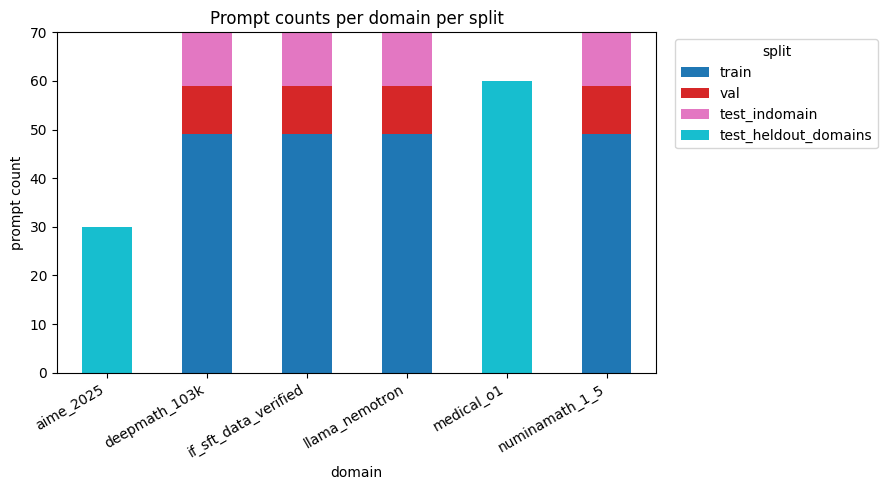

In [5]:

plot_counts = domain_split_counts.drop(index="all")[SPLIT_NAMES]
ax = plot_counts.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="tab10")
ax.set_ylabel("prompt count")
ax.set_xlabel("domain")
ax.set_title("Prompt counts per domain per split")
ax.legend(title="split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 3. Degeneration-rate analysis

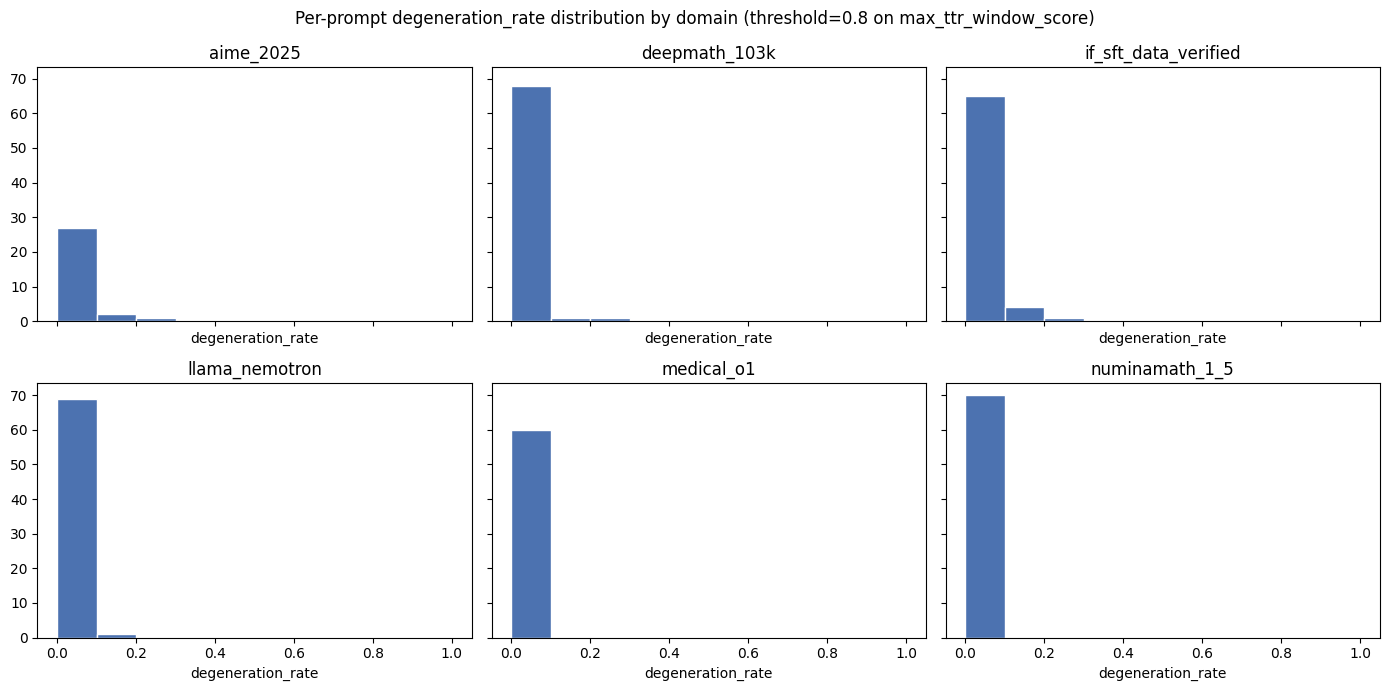

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, domain in zip(axes.flat, DOMAINS):
    vals = prompt_stats_df.loc[prompt_stats_df["domain"] == domain, "degeneration_rate"]
    ax.hist(vals, bins=np.linspace(0, 1, 11), color="#4C72B0", edgecolor="white")
    ax.set_title(domain)
    ax.set_xlabel("degeneration_rate")
fig.suptitle("Per-prompt degeneration_rate distribution by domain (threshold=0.8 on max_ttr_window_score)")
plt.tight_layout()
plt.show()


In [7]:

degeneration_summary = (
    prompt_stats_df.groupby("domain")["degeneration_rate"]
    .agg(mean_degeneration_rate="mean", max_degeneration_rate="max", n_prompts="count")
    .reindex(DOMAINS)
)

# Length-cap rate: fraction of *rollouts* that hit max_new_tokens without an EOS stop,
# recomputed directly from generations_df (not assumed).
length_cap_summary = (
    generations_df.assign(hit_cap=generations_df["stop_reason"] == "length")
    .groupby("domain")["hit_cap"]
    .mean()
    .rename("length_cap_rate")
    .reindex(DOMAINS)
)

summary_table = degeneration_summary.join(length_cap_summary)
summary_table


,mean_degeneration_rate,max_degeneration_rate,n_prompts,length_cap_rate
domain,,,,
aime_2025,0.013333,0.2,30,0.080000
deepmath_103k,0.004286,0.2,70,0.091429
if_sft_data_verified,0.010000,0.3,70,0.108571
llama_nemotron,0.001429,0.1,70,0.218571
medical_o1,0.000000,0.0,60,0.000000
numinamath_1_5,0.000000,0.0,70,0.081429


In [8]:

overall_mean = prompt_stats_df["degeneration_rate"].mean()
overall_max_single_prompt = prompt_stats_df["degeneration_rate"].max()
# The "very low overall" finding is about per-domain *mean* degeneration_rate (a handful of
# individual prompts can still spike, e.g. if_sft_data_verified's max of 0.3 below) -- so check
# that against the per-domain means, not the single highest individual prompt.
highest_domain_mean = degeneration_summary["mean_degeneration_rate"].max()
highest_length_cap_domain = length_cap_summary.idxmax()
highest_length_cap_value = length_cap_summary.max()

low_overall = highest_domain_mean <= 0.05  # every domain's *mean* degeneration_rate is tiny
nemotron_highest = highest_length_cap_domain == "llama_nemotron"

print(f"Overall degeneration_rate across all {len(prompt_stats_df)} prompts: mean={overall_mean:.4f}, "
      f"highest single-prompt value={overall_max_single_prompt:.4f}")
print(f"Highest per-domain mean degeneration_rate: {highest_domain_mean:.4f} "
      f"({degeneration_summary['mean_degeneration_rate'].idxmax()})")
print(f"Domain with highest length-cap rate: {highest_length_cap_domain} ({highest_length_cap_value:.1%})")
print(f"Finding confirmed (low overall degeneration_rate, i.e. every domain's mean <= 5%)?  {low_overall}")
print(f"Finding confirmed (llama_nemotron highest length-cap rate)?  {nemotron_highest}")


Overall degeneration_rate across all 370 prompts: mean=0.0041, highest single-prompt value=0.3000
Highest per-domain mean degeneration_rate: 0.0133 (aime_2025)
Domain with highest length-cap rate: llama_nemotron (21.9%)
Finding confirmed (low overall degeneration_rate, i.e. every domain's mean <= 5%)?  True
Finding confirmed (llama_nemotron highest length-cap rate)?  True


**Finding, recomputed from the real pilot data above:** overall `degeneration_rate`
(fraction of rollouts per prompt whose max TTR-window score exceeds the 0.8 threshold) is
very low everywhere -- domain means range roughly 0-1.3%, and `medical_o1` / `numinamath_1_5`
never cross the threshold at all in this pilot (mean = max = 0.0). At the same time,
`llama_nemotron` has the clearly highest **length-cap rate** (~22% of its rollouts hit the
1024-token cap without ever emitting EOS), well above every other domain -- consistent with
degeneration often *forming* in llama_nemotron rollouts but getting cut off by
`max_new_tokens` before its window-max TTR score crosses 0.8. See Section 5 for a concrete,
hand-verified example of exactly this (`llama_nemotron_00055` / `rollout_idx=2`).

## 4. Loader helper: `load_example`

In [9]:

from safetensors.torch import load_file


def load_example(prompt_id: str, rollout_idx: int, layer: int | None = None) -> dict:
    '''Join generations + labels for one (prompt_id, rollout_idx), and try to load its
    cached activation tensor.

    Generation + label data is always available (drawn from the fully-populated
    `generations_df` / `labels_df` already loaded in this notebook). The activation
    tensor is only loaded if this exact (prompt_id, rollout_idx) pair has a row with
    status == "ok" in `activations_manifest_df` -- since the full activation cache has
    not been built yet, this will usually be False, in which case `activation` is
    returned as None with a clear note instead of raising.

    If `layer` is given, only that layer's [completion_len, hidden_size] slice is
    returned; otherwise the full [num_layers+1, completion_len, hidden_size] tensor.
    '''
    gen_row = generations_df.loc[
        (generations_df["prompt_id"] == prompt_id) & (generations_df["rollout_idx"] == rollout_idx)
    ]
    label_row = labels_df.loc[
        (labels_df["prompt_id"] == prompt_id) & (labels_df["rollout_idx"] == rollout_idx)
    ]
    if gen_row.empty or label_row.empty:
        raise KeyError(f"No generation/label row found for ({prompt_id!r}, {rollout_idx!r})")
    gen_row = gen_row.iloc[0]
    label_row = label_row.iloc[0]

    result = {
        "prompt_id": prompt_id,
        "rollout_idx": rollout_idx,
        "domain": gen_row["domain"],
        "generated_text": gen_row["generated_text"],
        "generated_token_ids": gen_row["generated_token_ids"],
        "num_tokens": int(gen_row["num_tokens"]),
        "stop_reason": gen_row["stop_reason"],
        "per_token_entropy": gen_row["per_token_entropy"],
        "ttr_window_score": label_row["ttr_window_score"],
        "lrs_window_score": label_row["lrs_window_score"],
        "entropy": label_row["entropy"],
        "activation": None,
        "activation_note": None,
    }

    manifest_hit = activations_manifest_df.loc[
        (activations_manifest_df["prompt_id"] == prompt_id)
        & (activations_manifest_df["rollout_idx"] == rollout_idx)
        & (activations_manifest_df["status"] == "ok")
    ]
    if manifest_hit.empty:
        result["activation_note"] = (
            f"No cached activation for ({prompt_id!r}, {rollout_idx!r}) -- activations/ is "
            "not fully populated yet (only 3 validation rows exist so far)."
        )
        return result

    act_path = manifest_hit.iloc[0]["path"]
    tensors = load_file(act_path)
    hidden_states = tensors["hidden_states"]  # [num_layers+1, completion_len, hidden_size]
    if layer is not None:
        hidden_states = hidden_states[layer]  # [completion_len, hidden_size]
    result["activation"] = hidden_states
    result["activation_note"] = f"Loaded cached activation from {act_path} (layer={layer})"
    return result


In [10]:

# Demo 1: a (prompt_id, rollout_idx) that DOES have a cached activation.
cached_example = load_example("llama_nemotron_00055", 2, layer=16)
print("=== cached activation example (llama_nemotron_00055, rollout_idx=2, layer=16) ===")
print(f"domain: {cached_example['domain']}, num_tokens: {cached_example['num_tokens']}, "
      f"stop_reason: {cached_example['stop_reason']}")
print(f"activation_note: {cached_example['activation_note']}")
print(f"activation shape: {None if cached_example['activation'] is None else tuple(cached_example['activation'].shape)}")


=== cached activation example (llama_nemotron_00055, rollout_idx=2, layer=16) ===
domain: llama_nemotron, num_tokens: 1024, stop_reason: length
activation_note: Loaded cached activation from /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_pilot/activations/llama_nemotron/llama_nemotron_00055/rollout_2.safetensors (layer=16)
activation shape: (1024, 4096)


In [11]:

# Demo 2: a (prompt_id, rollout_idx) that does NOT have a cached activation (the common case
# right now) -- shows the graceful missing-data path instead of erroring.
missing_example = load_example("deepmath_103k_00021", 3)
print("=== no cached activation example (deepmath_103k_00021, rollout_idx=3) ===")
print(f"domain: {missing_example['domain']}, num_tokens: {missing_example['num_tokens']}, "
      f"stop_reason: {missing_example['stop_reason']}")
print(f"activation_note: {missing_example['activation_note']}")
print(f"activation: {missing_example['activation']}")


=== no cached activation example (deepmath_103k_00021, rollout_idx=3) ===
domain: deepmath_103k, num_tokens: 49, stop_reason: eos
activation_note: No cached activation for ('deepmath_103k_00021', 3) -- activations/ is not fully populated yet (only 3 validation rows exist so far).
activation: None


## 5. Per-token visualization

In [12]:

def plot_token_signals(prompt_id: str, rollout_idx: int, window: tuple[int, int] | None = None, title_extra: str = ""):
    ex = load_example(prompt_id, rollout_idx)
    ttr = np.asarray(ex["ttr_window_score"], dtype=float)
    lrs = np.asarray(ex["lrs_window_score"], dtype=float)
    entropy = np.asarray(ex["entropy"], dtype=float)
    n = len(ttr)

    if window is None:
        start, end = 0, n
    else:
        start, end = window
        start = max(0, start)
        end = min(n, end)

    positions = np.arange(start, end)

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(positions, ttr[start:end], color="#C44E52")
    axes[0].axhline(0.8, color="gray", linestyle="--", linewidth=1, label="degeneration threshold (0.8)")
    axes[0].set_ylabel("TTR window\nscore")
    axes[0].legend(loc="upper left", fontsize=8)

    axes[1].plot(positions, lrs[start:end], color="#55A868")
    axes[1].set_ylabel("LRS window\nscore")

    axes[2].plot(positions, entropy[start:end], color="#4C72B0")
    axes[2].set_ylabel("entropy")
    axes[2].set_xlabel("token offset in completion")

    fig.suptitle(
        f"{prompt_id} / rollout_idx={rollout_idx}  (domain={ex['domain']}, "
        f"num_tokens={ex['num_tokens']}, stop_reason={ex['stop_reason']}){title_extra}"
    )
    plt.tight_layout()
    plt.show()
    return ex


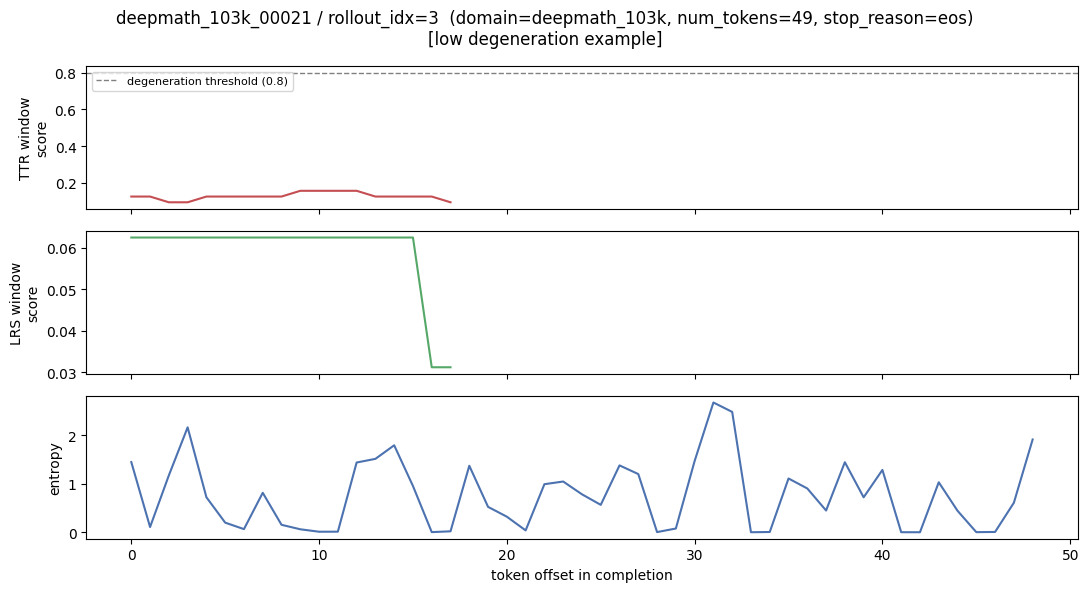

In [13]:

# Example A: low-degeneration rollout (max TTR-window score ~0.16 -- clean, non-repetitive).
_ = plot_token_signals("deepmath_103k_00021", 3, title_extra="\n[low degeneration example]")


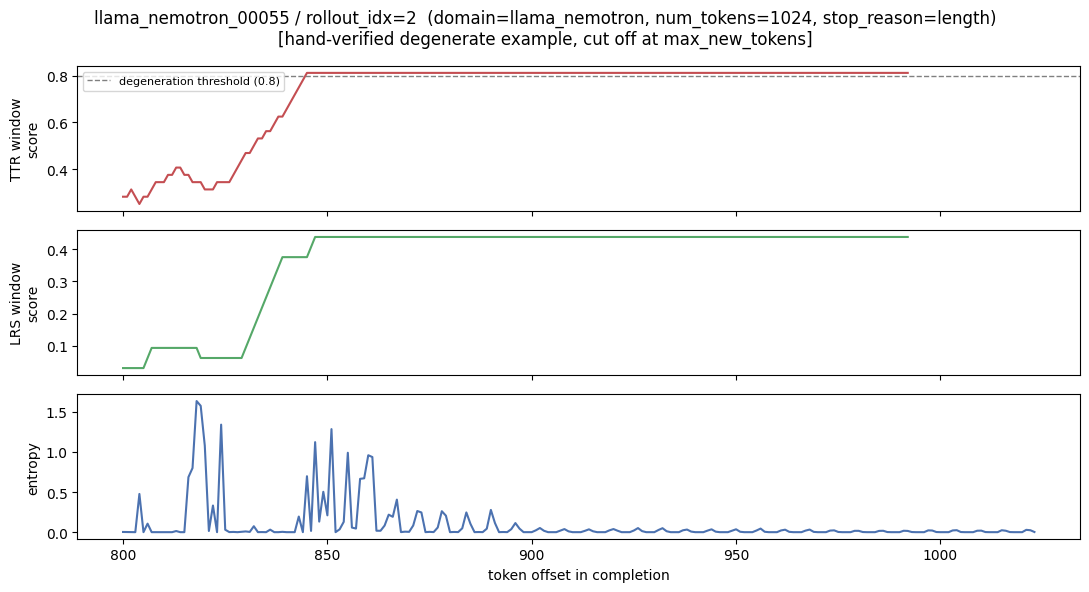

] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited[u-1] and visited


In [14]:

# Example B: llama_nemotron_00055 / rollout_idx=2 -- the hand-verified example from the pilot
# writeup: a real "visited[u-1] and visited[u-1] and ..." loop that starts forming around
# token offset ~849 and gets cut off at the 1024-token max_new_tokens cap (stop_reason="length")
# before its TTR-window score has climbed much past the 0.8 threshold. This is exactly the
# "forming but truncated" pattern behind llama_nemotron's high length-cap rate from Section 3.
ex_b = plot_token_signals(
    "llama_nemotron_00055", 2, window=(800, 1024),
    title_extra="\n[hand-verified degenerate example, cut off at max_new_tokens]",
)
print(ex_b["generated_text"][-200:])


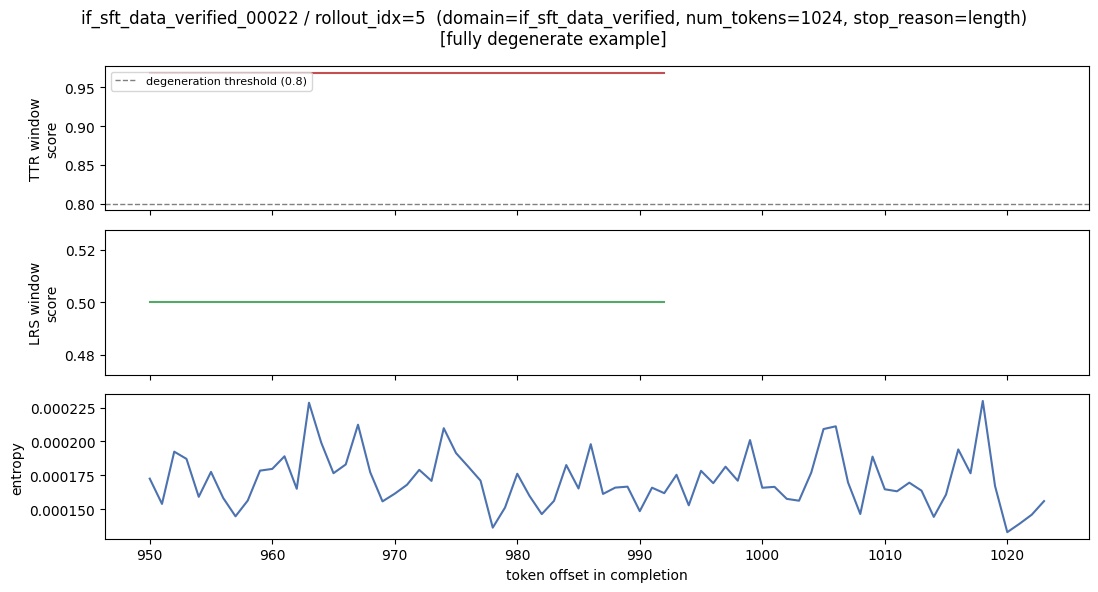

In [15]:

# Example C: a fully degenerate rollout from a different domain, for contrast -- a "do do do
# do ..." loop that reaches TTR-window score ~0.97 well before the 1024-token cap.
_ = plot_token_signals("if_sft_data_verified_00022", 5, window=(950, 1024), title_extra="\n[fully degenerate example]")


## 6. LLM-judge agreement summary (placeholder)

In [16]:

# This phase (LLM-judge labeling + agreement-with-heuristic-signals analysis) has not been
# run yet -- it is deliberately deferred for now. This cell checks for llm_judge/ data and
# reports a clear "not yet available" message instead of erroring or silently skipping the
# section, so the notebook's structure already anticipates this phase for when it is added.
llm_judge_dir = paths.llm_judge_dir(config)

llm_judge_files = list(llm_judge_dir.glob("**/*")) if llm_judge_dir.exists() else []
llm_judge_data_files = [p for p in llm_judge_files if p.is_file()]

if not llm_judge_dir.exists() or not llm_judge_data_files:
    print(f"llm_judge/ directory: {llm_judge_dir}")
    print(f"  exists: {llm_judge_dir.exists()}, data files found: {len(llm_judge_data_files)}")
    print()
    print("NOT YET AVAILABLE: LLM-judge labeling has been entirely deferred for this pilot. "
          "Once llm_judge/ is populated, this cell should load it and compute agreement "
          "(e.g. correlation / confusion matrix) between judge labels and the TTR/LRS "
          "heuristic signals from Section 3.")
else:
    print(f"Found {len(llm_judge_data_files)} file(s) under {llm_judge_dir} -- "
          "update this cell to actually load and analyze them.")


llm_judge/ directory: /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_pilot/llm_judge
  exists: True, data files found: 0

NOT YET AVAILABLE: LLM-judge labeling has been entirely deferred for this pilot. Once llm_judge/ is populated, this cell should load it and compute agreement (e.g. correlation / confusion matrix) between judge labels and the TTR/LRS heuristic signals from Section 3.
